In [26]:
import json
import numpy as np
import pandas as pd
import spacy

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [27]:
with open("intentsnew.json", "r", encoding="utf-8") as file:
    data = json.load(file)

print("✅ Dataset Loaded Successfully!")

✅ Dataset Loaded Successfully!


In [28]:
num_intents = len(data['intents'])
print("Number of Intents:", num_intents)

Number of Intents: 41


In [29]:
total_patterns = sum(len(intent['patterns']) for intent in data['intents'])
print("Total Questions:", total_patterns)



Total Questions: 10248


In [30]:
patterns = []
tags = []

for intent in data['intents']:
    for pattern in intent['patterns']:
        patterns.append(pattern)
        tags.append(intent['tag'])

print("Total Patterns Extracted:", len(patterns))
print("Total Labels Extracted:", len(tags))

Total Patterns Extracted: 10248
Total Labels Extracted: 10248


In [31]:
import spacy

nlp = spacy.load("en_core_web_lg")

In [32]:
def preprocess_text(text):

    doc = nlp(text.lower())

    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and token.is_alpha
    ]

    return " ".join(tokens)


processed_patterns = []

for text in patterns:
    processed_patterns.append(
        preprocess_text(text)
    )

print("Preprocessing Completed!")
print("Total Processed Patterns:", len(processed_patterns))

Preprocessing Completed!
Total Processed Patterns: 10248


In [33]:
for i in range(5):
    
    print("Original :", patterns[i])
    print("Processed:", processed_patterns[i])
    print("-"*50)

Original : Hi
Processed: hi
--------------------------------------------------
Original : How are you?
Processed: 
--------------------------------------------------
Original : Is anyone there?
Processed: 
--------------------------------------------------
Original : Hello
Processed: hello
--------------------------------------------------
Original : Good day
Processed: good day
--------------------------------------------------


In [35]:
X = processed_patterns


In [36]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(tags)

print("X size:", len(X))
print("y size:", len(y))

print("Number of Classes:", len(encoder.classes_))

X size: 10248
y size: 10248
Number of Classes: 41


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 8198
Testing Samples : 2050


In [38]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(oov_token="<OOV>")

tokenizer.fit_on_texts(X_train)

vocab_size = len(tokenizer.word_index) + 1

print("Vocabulary Size:", vocab_size)

Vocabulary Size: 209


In [39]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print(X_train_seq[0])

[18, 9]


In [40]:
max_length = max(len(seq) for seq in X_train_seq)

print("Maximum Sequence Length:", max_length)

Maximum Sequence Length: 6


In [41]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)

print("Train Shape:", X_train_pad.shape)
print("Test Shape :", X_test_pad.shape)

Train Shape: (8198, 6)
Test Shape : (2050, 6)


In [42]:
print(X_train[0])
print(X_train_seq[0])
print(X_train_pad[0])

cutoff help
[18, 9]
[18  9  0  0  0  0]


In [43]:
print("Vocabulary Size:", vocab_size)
print("Maximum Sequence Length:", max_length)
print("Train Shape:", X_train_pad.shape)
print("Test Shape:", X_test_pad.shape)

Vocabulary Size: 209
Maximum Sequence Length: 6
Train Shape: (8198, 6)
Test Shape: (2050, 6)


In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

num_classes = len(encoder.classes_)

model = Sequential([
    
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    ),

    LSTM(128),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(num_classes, activation='softmax')
])

model.summary()

C:\Users\prasa\OneDrive\Desktop\Data_Scientist\PHASE - II\tfenv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [45]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32
)

Epoch 1/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.4628 - loss: 2.0274 - val_accuracy: 0.9543 - val_loss: 0.2485
Epoch 2/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9588 - loss: 0.2027 - val_accuracy: 0.9634 - val_loss: 0.1281
Epoch 3/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9672 - loss: 0.1202 - val_accuracy: 0.9610 - val_loss: 0.1030
Epoch 4/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9701 - loss: 0.0859 - val_accuracy: 0.9677 - val_loss: 0.1069
Epoch 5/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9684 - loss: 0.0825 - val_accuracy: 0.9695 - val_loss: 0.0891
Epoch 6/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9726 - loss: 0.0618 - val_accuracy: 0.9689 - val_loss: 0.0843
Epoch 7/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9747 - loss: 0.0564 - val_accuracy: 0.9695 - val_loss: 0.0834
Epoch 8/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9765 - loss: 0.0548 - val_accuracy: 0.

In [47]:
loss, accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("Test Accuracy:", accuracy)

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9732 - loss: 0.1088
Test Accuracy: 0.9731707572937012


In [48]:
y_pred = model.predict(X_test_pad)

y_pred = y_pred.argmax(axis=1)

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [49]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

                                 precision    recall  f1-score   support

           Eligibility Criteria       1.00      1.00      1.00        49
                         FMCIII       0.98      1.00      0.99        49
Steps to complete the admission       1.00      1.00      1.00        49
                          about       0.93      0.27      0.41        49
                        canteen       0.98      0.98      0.98        50
                          clubs       1.00      0.98      0.99        49
                 college intake       0.98      1.00      0.99        50
                    computerhod       1.00      1.00      1.00        49
                         course       1.00      1.00      1.00        54
                        creator       1.00      0.98      0.99        51
                         cutoff       1.00      1.00      1.00        50
                       document       1.00      1.00      1.00        51
                          event       1.00      0.

In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.973170731707317
Precision: 0.9837011498199447
Recall   : 0.973170731707317
F1 Score : 0.9719557037975863


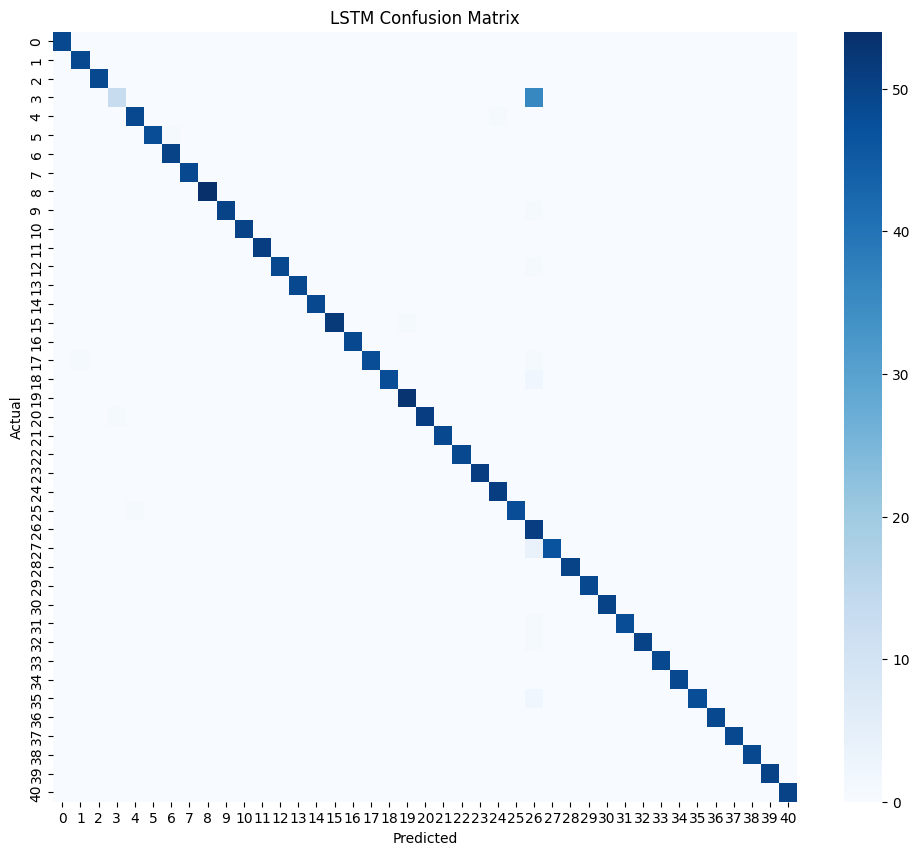

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [52]:
lstm_accuracy = accuracy
lstm_precision = precision
lstm_recall = recall
lstm_f1 = f1

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

num_classes = len(encoder.classes_)

gru_model = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    ),

    GRU(128),

    Dropout(0.3),

    Dense(64, activation='relu'),

    Dense(num_classes, activation='softmax')
])

gru_model.summary()

C:\Users\prasa\OneDrive\Desktop\Data_Scientist\PHASE - II\tfenv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [54]:
gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [55]:
gru_history = gru_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=32
)

Epoch 1/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.2931 - loss: 2.5122 - val_accuracy: 0.8902 - val_loss: 0.7150
Epoch 2/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9390 - loss: 0.3722 - val_accuracy: 0.9598 - val_loss: 0.1687
Epoch 3/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9591 - loss: 0.1593 - val_accuracy: 0.9640 - val_loss: 0.1393
Epoch 4/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9678 - loss: 0.1071 - val_accuracy: 0.9707 - val_loss: 0.1226
Epoch 5/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9666 - loss: 0.0904 - val_accuracy: 0.9659 - val_loss: 0.1412
Epoch 6/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9713 - loss: 0.0750 - val_accuracy: 0.9726 - val_loss: 0.1135
Epoch 7/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9712 - loss: 0.0729 - val_accuracy: 0.9683 - val_loss: 0.1149
Epoch 8/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9716 - loss: 0.0669 - val_accuracy: 0

In [56]:
loss, gru_accuracy = gru_model.evaluate(
    X_test_pad,
    y_test
)

print("GRU Test Accuracy:", gru_accuracy)

65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9683 - loss: 0.1425
GRU Test Accuracy: 0.9682926535606384


In [57]:
gru_pred = gru_model.predict(X_test_pad)

gru_pred = gru_pred.argmax(axis=1)

65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

gru_acc = accuracy_score(y_test, gru_pred)

gru_precision = precision_score(
    y_test,
    gru_pred,
    average='weighted'
)

gru_recall = recall_score(
    y_test,
    gru_pred,
    average='weighted'
)

gru_f1 = f1_score(
    y_test,
    gru_pred,
    average='weighted'
)

print("Accuracy :", gru_acc)
print("Precision:", gru_precision)
print("Recall   :", gru_recall)
print("F1 Score :", gru_f1)

Accuracy : 0.9682926829268292
Precision: 0.9720331973742032
Recall   : 0.9682926829268292
F1 Score : 0.9683803460872523


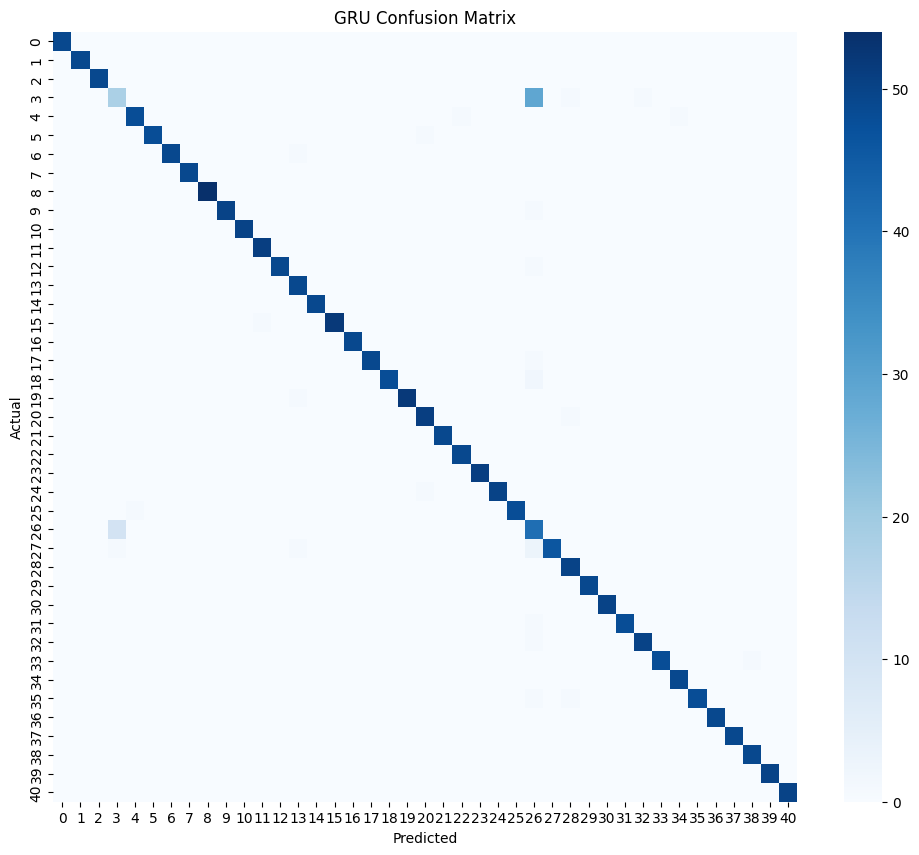

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, gru_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("GRU Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [60]:
model.save("college_chatbot_gru.keras")

In [61]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [62]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

In [63]:
max_length = 20

In [64]:
with open("max_length.pkl", "wb") as f:
    pickle.dump(max_length, f)

In [65]:
from tensorflow.keras.models import load_model
import pickle

model = load_model("college_chatbot_gru.keras")

with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

with open("label_encoder.pkl", "rb") as f:
    encoder = pickle.load(f)

with open("max_length.pkl", "rb") as f:
    max_length = pickle.load(f)

print("All files loaded successfully")

All files loaded successfully


In [66]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

def predict_intent(text):

    seq = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(
        seq,
        maxlen=max_length,
        padding="post"
    )

    pred = model.predict(padded)

    tag = encoder.inverse_transform(
        [np.argmax(pred)]
    )[0]

    return tag

In [67]:
print(predict_intent("hostel fee"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
hostel


In [70]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

text = "what about fees"

sequence = tokenizer.texts_to_sequences([text])

print("Sequence:", sequence)

padded = pad_sequences(
    sequence,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Padded:", padded)

prediction = model.predict(
    padded,
    verbose=0
)[0]

top_indices = np.argsort(prediction)[-5:][::-1]

print("\nTop 5 Predictions\n")

for idx in top_indices:

    tag = encoder.inverse_transform([idx])[0]

    print(
        tag,
        "->",
        round(float(prediction[idx]), 4)
    )

Sequence: [[1, 1, 1]]
Padded: [[1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

Top 5 Predictions

menu -> 0.6189
canteen -> 0.289
course -> 0.0889
syllabus -> 0.0024
hours -> 0.0003


In [74]:
count = 0

for intent in data["intents"]:
    for pattern in intent["patterns"]:
        if "fees" in pattern.lower():
            count += 1

print(count)

257


In [76]:
print(tokenizer.num_words)

None


In [78]:
print(list(tokenizer.word_index.keys())[:50])

['<OOV>', 'information', 'explain', 'detail', 'tell', 'question', 'query', 'need', 'help', 'relate', 'college', 'fee', 'hostel', 'facility', 'admission', 'document', 'number', 'cutoff', 'library', 'canteen', 'event', 'course', 'sport', 'principal', 'rag', 'trust', 'uniform', 'syllabus', 'step', 'fmciii', 'scholarship', 'club', 'infrastructure', 'floor', 'menu', 'eligibility', 'creator', 'placement', 'hour', 'vacation', 'criterion', 'goodbye', 'intake', 'random', 'computerhod', 'swear', 'location', 'ithod', 'complete', 'extchod']
